<a href="https://colab.research.google.com/github/Faith-InsightData/-California-Housing-Data-Analysis-/blob/main/Principal_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Introduction to Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical technique that helps in reducing the dimensionality of a dataset while preserving as much information as possible. It transforms the data into a new set of variables, the principal components, which are orthogonal and ranked according to the variance they capture from the original dataset.

## Why Use PCA?

- **Dimensionality Reduction**: Simplifies the data by reducing the number of dimensions without significant loss of information.
- **Visualization**: Makes it easier to visualize complex data by reducing dimensions to 2D or 3D.
- **Noise Reduction**: Improves data quality by eliminating variations that are less important.
- **Feature Extraction**: New features generated from PCA can be used for further machine learning processing.

## Concept and Purpose

PCA finds the directions of maximum variance in high-dimensional data and projects it onto a new subspace with equal or fewer dimensions. The principal components are the directions where the data varies the most. This reduction in dimensions is achieved while preserving as much of the data's variation as possible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example dataset
data = np.array([[2.5, 1.5], [0.5, 1.1], [2.2, 2.4], [1.9, 0.7], [3.1, 2.9]])

# Standardizing the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)

## Applying PCA to the Dataset

Next, we will apply PCA to the standardized dataset to identify the principal components that capture the most variance within the data. This process helps in reducing the dimensionality while retaining essential information.


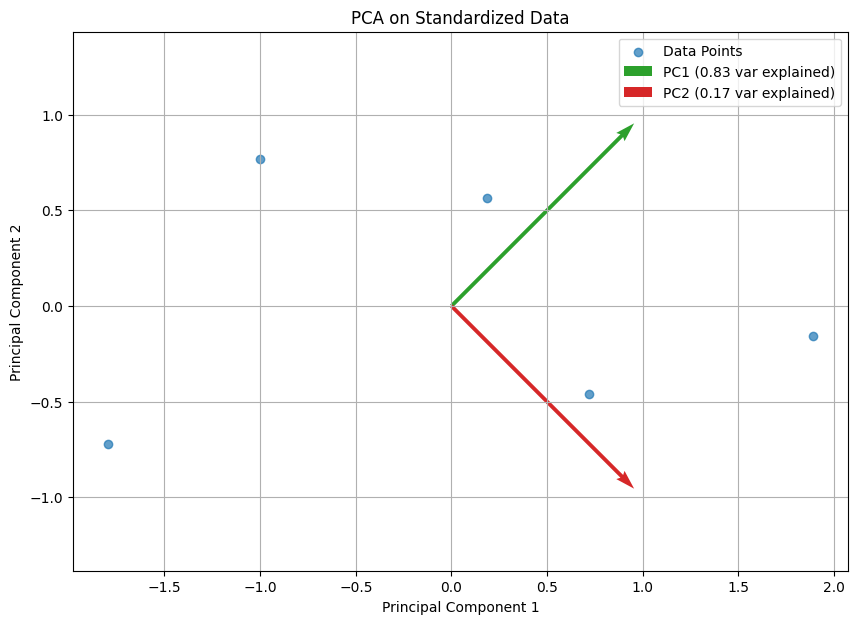

In [ ]:
pca = PCA(n_components=2)
pca.fit(data_normalized)
transformed_data = pca.transform(data_normalized)

# Plotting PCA
plt.figure(figsize=(10, 7))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], alpha=0.7, label='Data Points')
for i, (component, var) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    plt.quiver(0, 0, component[0], component[1], scale=3, color=f"C{i+2}", width=0.005,
               label=f'PC{i+1} ({var:.2f} var explained)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Standardized Data')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

### Explanation of the PCA Plot

In the plot above, the arrows represent the principal components of the dataset. Each arrow direction shows where the data has the most variance, i.e., where the data spreads out the most. The length of the arrow indicates the amount of variance captured by each principal component:

- **PC1** captures the majority of the variance, showing the primary direction of data spread.
- **PC2** captures the remaining variance and is orthogonal to PC1, highlighting a lesser but still significant direction of variability.


## PCA on 3D Data

Now, we will explore PCA on a 3-dimensional dataset to see how it can reduce dimensions from 3D to 2D while attempting to retain the most informative aspects of the data.


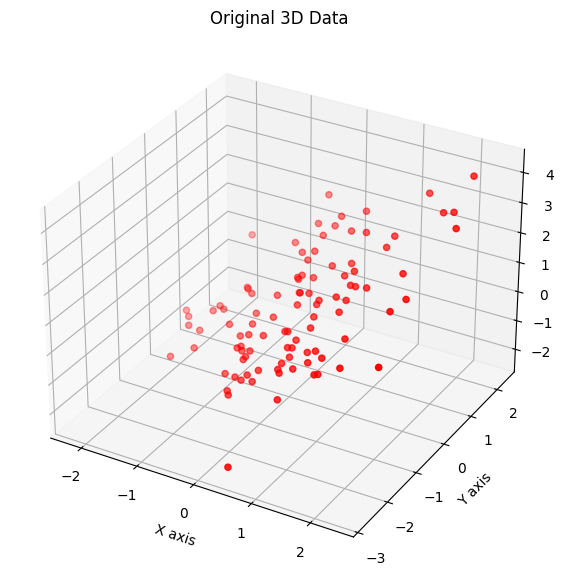

In [ ]:
## Create and Plot 3D Data
# Generating random data with a clear plane
np.random.seed(0)
X = np.random.normal(loc=0, scale=1, size=(100, 3))
X[:, 2] = X[:, 0] + X[:, 1] + np.random.normal(loc=0, scale=0.1, size=100)

# Plotting the original 3D data
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='r', marker='o')
ax.set_title('Original 3D Data')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()


## Projecting 3D Data to 2D Using PCA

By applying PCA to 3D data, we can reduce the dimensions to 2D. This process involves identifying the two principal components that capture the most variance and projecting the original data onto a new plane defined by these components.


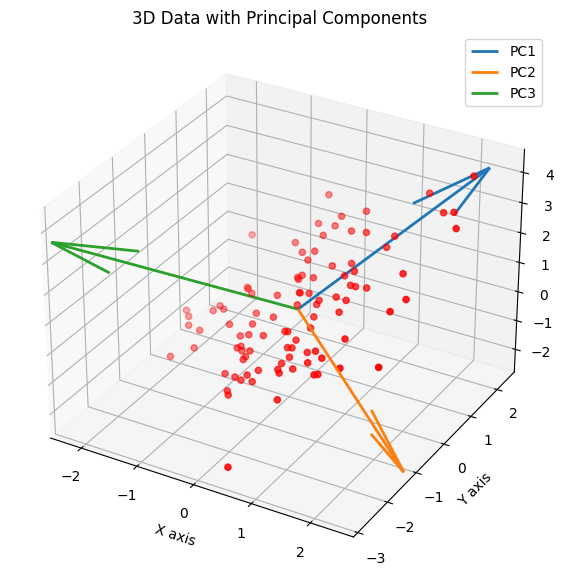

In [ ]:
# Plot 3D Data with PCA Vectors
# Performing PCA
pca_3d = PCA(n_components=3)
pca_3d.fit(X)
X_pca_3d = pca_3d.transform(X)

# Extracting principal components
components_3d = pca_3d.components_

# Plotting 3D data with PCA vectors
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='r', marker='o')
mean_3d = np.mean(X, axis=0)
for i, v in enumerate(components_3d):
    start, end = mean_3d, mean_3d + 5 * v
    ax.quiver(start[0], start[1], start[2], end[0], end[1], end[2], color=f'C{i}', linewidth=2, label=f'PC{i+1}')
ax.set_title('3D Data with Principal Components')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.legend()
plt.show()

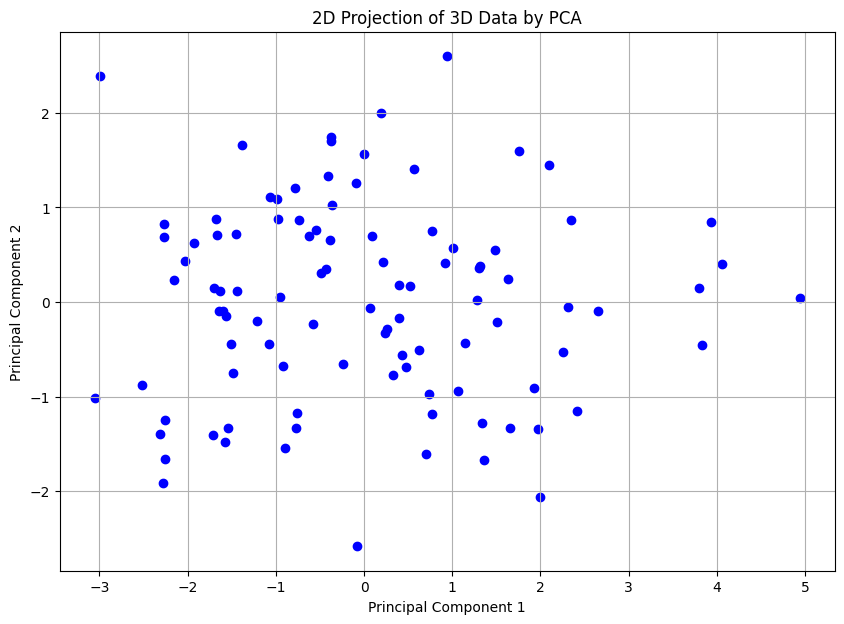

In [ ]:
# Plot the 2D Projection by PCA
# Reducing to 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# Plotting the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='blue', marker='o')
plt.title('2D Projection of 3D Data by PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

The final plot you've displayed represents the 2D projection of the original 3D data after applying Principal Component Analysis (PCA).

### Understanding the 2D Projection Plot

1. **Axes**:
   - **Principal Component 1 (X-axis)**: This axis represents the first principal component, which is the direction of maximum variance in the original 3D dataset. It captures the largest part of the variance among the features.
   - **Principal Component 2 (Y-axis)**: This axis represents the second principal component. It is orthogonal (perpendicular) to the first principal component and captures the second largest amount of variance in the data.

2. **Data Points**:
   - The blue dots represent the original data points from the 3D dataset, now transformed and projected onto the new 2D space formed by the two principal components. Each point’s position on this plot is determined by its coordinates along these two principal components.

3. **Variance and Data Spread**:
   - The spread of the points along each axis indicates how much variance each principal component captures. A wider spread along an axis suggests more variance captured in that direction.
   - The relative density or dispersion of points can provide insights into the underlying structure of the data, such as clustering tendencies or the presence of outliers.

4. **Dimensionality Reduction**:
   - This plot is a result of reducing the dimensionality of the data from three dimensions to two while attempting to retain as much information as possible. The transformation is designed to maximize the variance represented in the 2D space, thus preserving important characteristics and relationships present in the original 3D data.

5. **Interpretation**:
   - By observing this plot, you can infer patterns, trends, and relationships that were not immediately apparent in the higher-dimensional space. PCA simplifies the complexity of high-dimensional data, making it easier to perform further analysis, visualize patterns, and possibly identify clusters or groups within the data.

### Practical Implications

This visualization is particularly useful in exploratory data analysis, where understanding the underlying structure of the data is crucial. For instance, if this data represents different observations or experimental outcomes, the plot can help identify how these observations differ primarily and whether there are any notable correlations or groupings.